In [3]:
import os

base = "/content/drive/MyDrive/jeans_project"

os.makedirs(base + "/data", exist_ok=True)
os.makedirs(base + "/runs", exist_ok=True)

In [4]:
import torch
torch.cuda.is_available()

True

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.7 MB/s eta 0:00:00


In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="lALnORli8jMqO0qiw5Rd")
project = rf.workspace("ilefs-workspace").project("denim-vkqla-p124v")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 85.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Denim-1 in yolov11:: 100%|██████████| 4203/4203 [00:01<00:00, 2528.29it/s]


In [7]:
!ls /content

Denim-1  drive	sample_data


In [8]:
!mv /content/Denim-1 /content/drive/MyDrive/jeans_project/data/dataset

In [14]:
!ls /content/drive/MyDrive/jeans_project/data/dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [9]:
!yolo detect train \
data=/content/drive/MyDrive/jeans_project/data/dataset/data.yaml \
model=yolo11s.pt \
epochs=60 \
imgsz=640 \
batch=8 \
project=/content/drive/MyDrive/jeans_project/runs \
name=training11m

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/jeans_project/data/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=

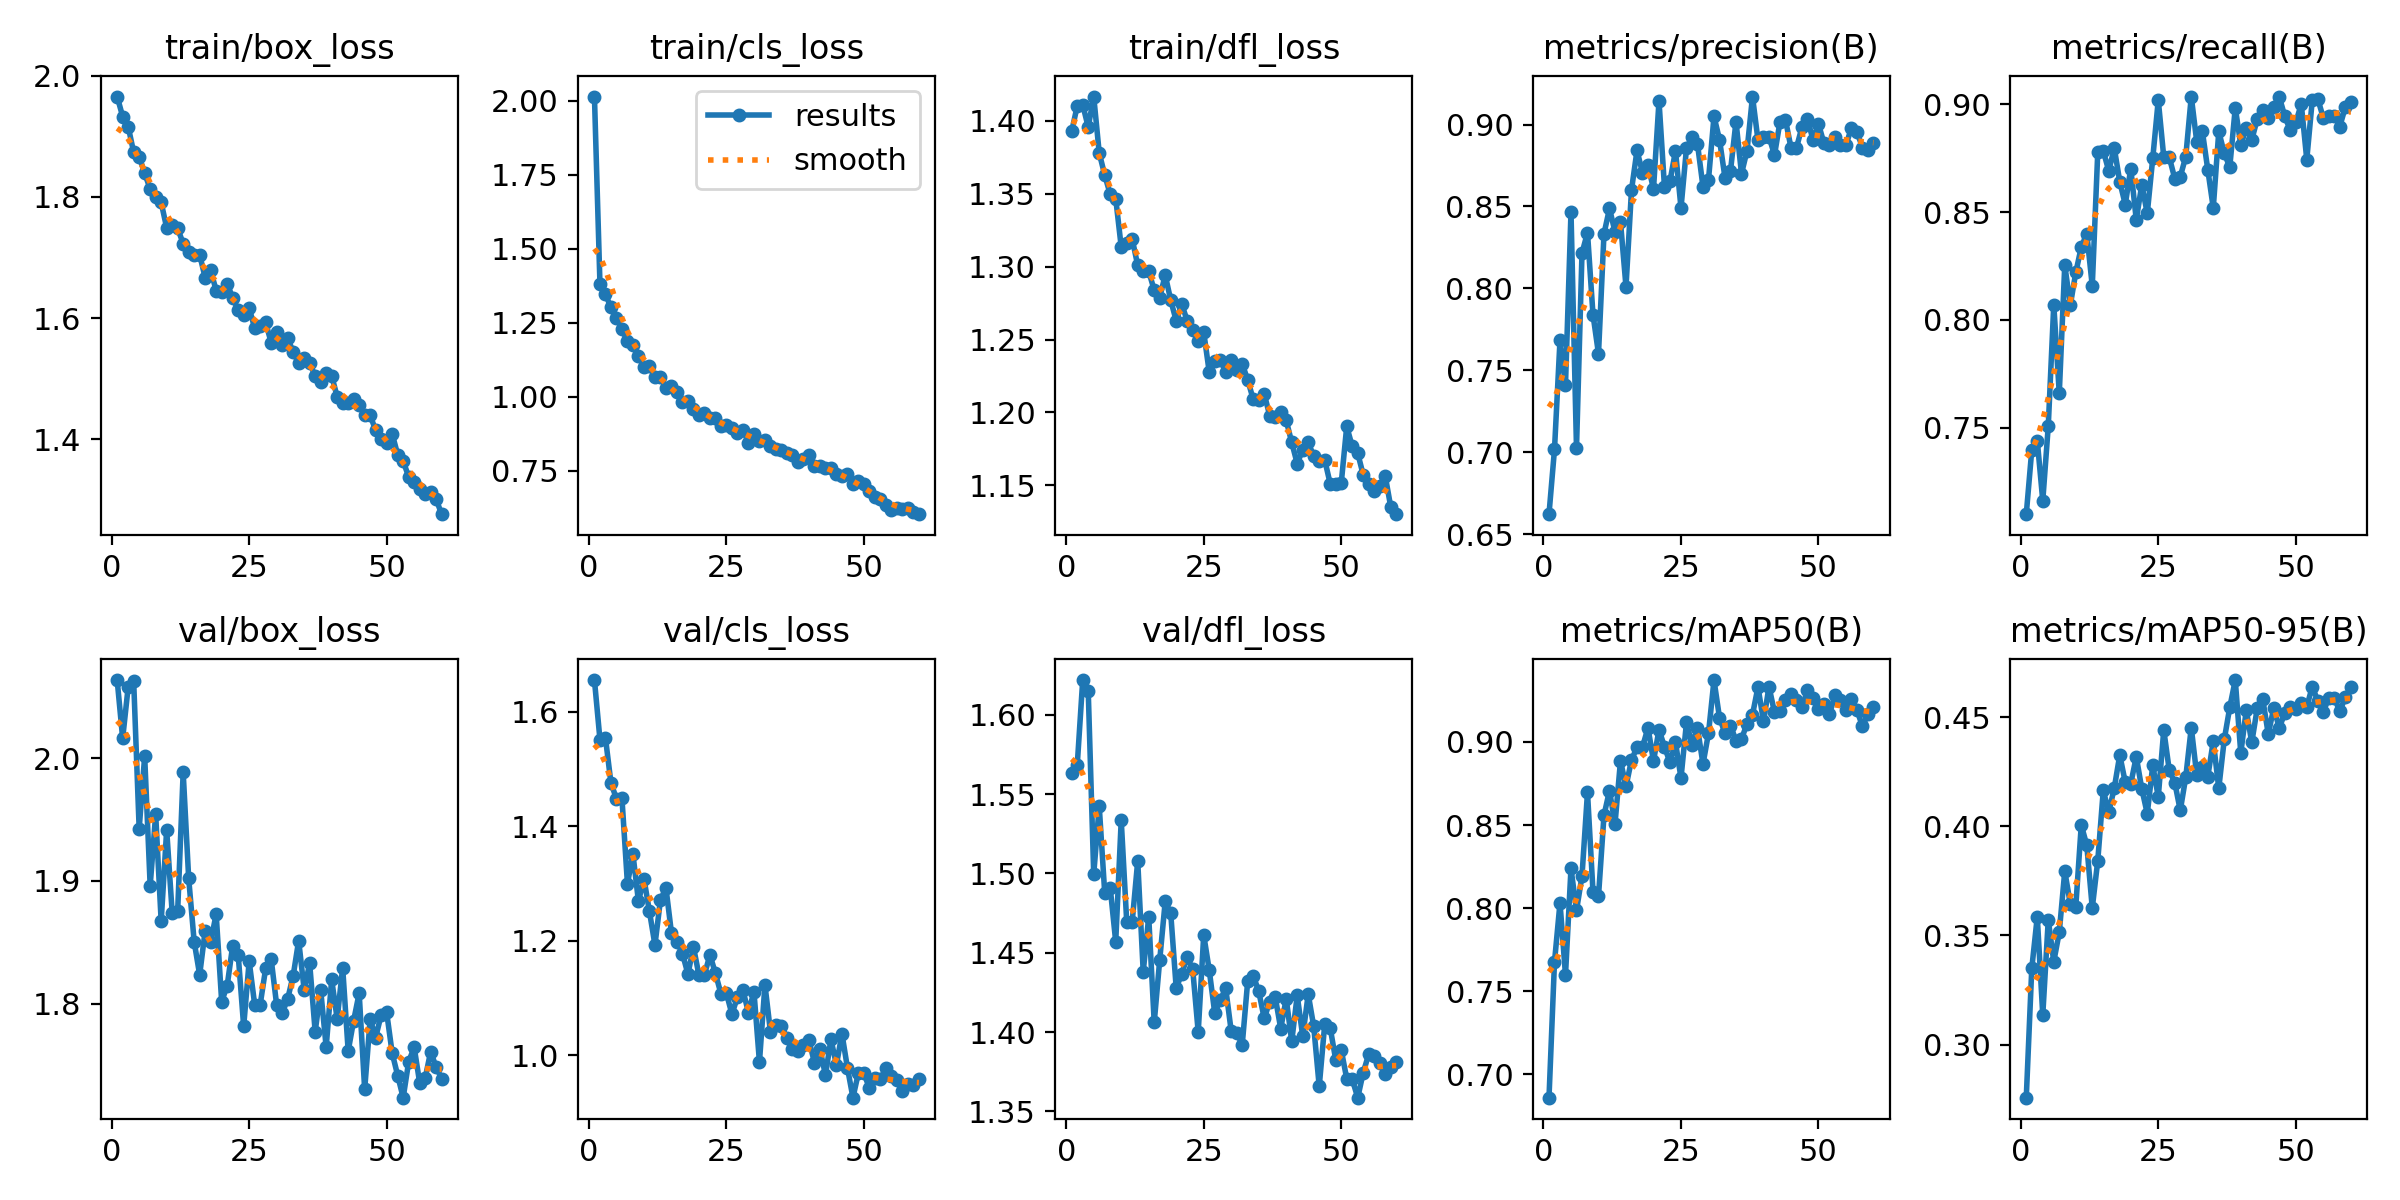

In [10]:
from IPython.display import Image
Image("/content/drive/MyDrive/jeans_project/runs/training11m/results.png")

In [11]:
import pandas as pd

# Chemin vers ton results.csv
csv_path = "/content/drive/MyDrive/jeans_project/runs/training11m/results.csv"

# Lire et afficher
df = pd.read_csv(csv_path)
df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,84.068,1.96558,2.01457,1.39293,0.66233,0.70977,0.68605,0.27570,2.06394,1.65505,1.56336,0.000474,0.000474,0.000474
1,2,137.740,1.93257,1.38282,1.41026,0.70181,0.73951,0.76763,0.33488,2.01631,1.55122,1.56811,0.000935,0.000935,0.000935
2,3,191.404,1.91608,1.34586,1.41115,0.76833,0.74393,0.80318,0.35857,2.05827,1.55411,1.62188,0.001380,0.001380,0.001380
3,4,244.915,1.87363,1.30258,1.39580,0.74124,0.71597,0.75978,0.31354,2.06312,1.47539,1.61527,0.001358,0.001358,0.001358
4,5,298.049,1.86584,1.26746,1.41674,0.84664,0.75070,0.82393,0.35720,1.94251,1.44780,1.49947,0.001335,0.001335,0.001335
5,6,351.300,1.83968,1.22752,1.37809,0.70265,0.80711,0.79860,0.33799,2.00187,1.44854,1.54246,0.001311,0.001311,0.001311
6,7,404.850,1.81258,1.18784,1.36283,0.82161,0.76585,0.81937,0.35149,1.89614,1.29929,1.48767,0.001288,0.001288,0.001288
7,8,458.342,1.79954,1.17622,1.34971,0.83403,0.82552,0.86968,0.37950,1.95444,1.35122,1.49095,0.001264,0.001264,0.001264
8,9,512.820,1.79095,1.13742,1.34676,0.78401,0.80671,0.80990,0.36452,1.86716,1.26863,1.45690,0.001240,0.001240,0.001240
9,10,566.478,1.74908,1.10119,1.31354,0.76017,0.82199,0.80719,0.36319,1.94171,1.30837,1.53353,0.001217,0.001217,0.001217


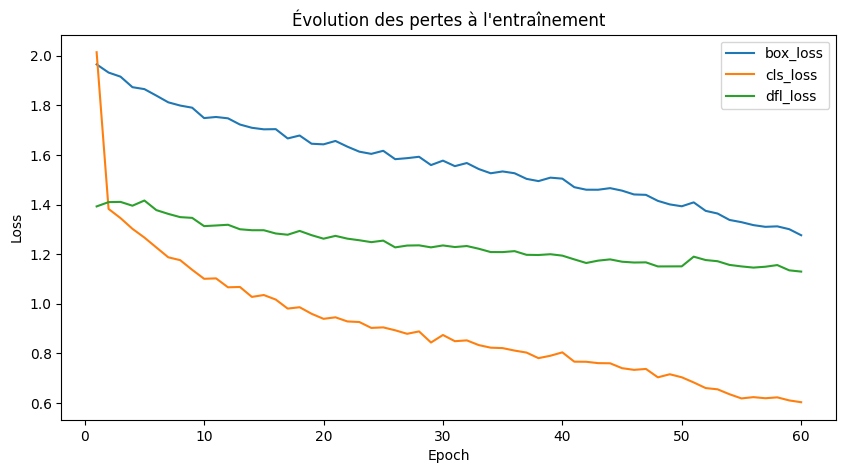

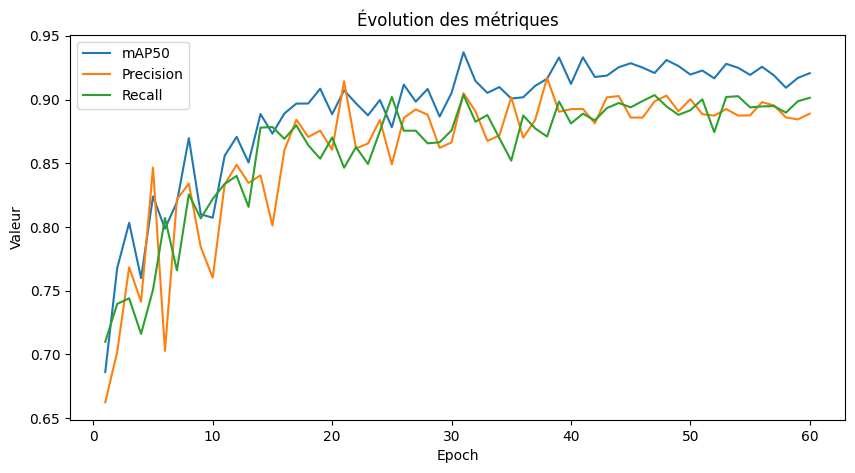

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire le CSV results.csv
csv_path = "/content/drive/MyDrive/jeans_project/runs/training11m/results.csv"
df = pd.read_csv(csv_path)

# Afficher les colonnes clés
df[['epoch','train/box_loss','train/cls_loss','train/dfl_loss',
    'metrics/precision(B)','metrics/recall(B)','metrics/mAP50(B)','metrics/mAP50-95(B)']]

# Tracer les pertes
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train/box_loss'], label='box_loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='cls_loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='dfl_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution des pertes à l\'entraînement')
plt.legend()
plt.show()

# Tracer les métriques
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.xlabel('Epoch')
plt.ylabel('Valeur')
plt.title('Évolution des métriques')
plt.legend()
plt.show()